# 🌾 AgroSentinel India — EDA & Model Analysis
## ML-Powered Farm Decision Support System
**Student:** GB Abhilash | **Course:** MCA | **Domain:** Agriculture AI
**SDG 2 — Zero Hunger | SDG 15 — Life on Land**
**Dataset:** Kaggle Crop Production India + Rainfall India + Crop Yield India


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (14, 6)
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

# Paths
BASE_DIR   = os.path.dirname(os.path.dirname(os.path.abspath('.')))
DS_DIR     = '../datasets'
MODEL_DIR  = '../ml_models'

print("✅ Libraries loaded successfully")
print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Seaborn : {sns.__version__}")


✅ Libraries loaded successfully
Pandas  : 2.2.3
NumPy   : 2.1.3
Seaborn : 0.13.2


## 📂 Step 1 — Load Datasets

In [3]:
# Load all 3 datasets
prod_df  = pd.read_csv(f'{DS_DIR}/crop_production.csv')
yield_df = pd.read_csv(f'{DS_DIR}/crop_yield.csv')
rain_df  = pd.read_csv(f'{DS_DIR}/rainfall in india 1901-2015.csv')

print(f"✅ Crop Production : {prod_df.shape[0]:,} rows × {prod_df.shape[1]} columns")
print(f"✅ Crop Yield      : {yield_df.shape[0]:,} rows × {yield_df.shape[1]} columns")
print(f"✅ Rainfall India  : {rain_df.shape[0]:,} rows × {rain_df.shape[1]} columns")
print()
print("Crop Production Columns:", list(prod_df.columns))
print("Crop Yield Columns     :", list(yield_df.columns))
print("Rainfall Columns       :", list(rain_df.columns))


✅ Crop Production : 246,091 rows × 7 columns
✅ Crop Yield      : 19,689 rows × 10 columns
✅ Rainfall India  : 4,116 rows × 19 columns

Crop Production Columns: ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']
Crop Yield Columns     : ['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']
Rainfall Columns       : ['SUBDIVISION', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec']


## 🔍 Step 2 — First Look at Data

In [4]:
print("=== CROP PRODUCTION — First 5 rows ===")
display(prod_df.head())
print()
print("=== CROP YIELD — First 5 rows ===")
display(yield_df.head())


=== CROP PRODUCTION — First 5 rows ===


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0



=== CROP YIELD — First 5 rows ===


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


## 🧹 Step 3 — Missing Values & Data Quality

In [5]:
print("=== MISSING VALUES — Crop Production ===")
missing = prod_df.isnull().sum()
missing_pct = (missing / len(prod_df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0])

print()
print("=== DATA TYPES ===")
display(prod_df.dtypes.to_frame('Type'))

print()
print(f"Total records (before cleaning) : {prod_df.shape[0]:,}")
print(f"Duplicate rows                  : {prod_df.duplicated().sum():,}")


=== MISSING VALUES — Crop Production ===


,Missing Count,Missing %
Production,3730,1.52



=== DATA TYPES ===


,Type
State_Name,object
District_Name,object
Crop_Year,int64
Season,object
Crop,object
Area,float64
Production,float64



Total records (before cleaning) : 246,091
Duplicate rows                  : 0


## ⚙️ Step 4 — Data Preprocessing

In [6]:
# Standardize column names
prod_df.columns = prod_df.columns.str.strip().str.lower().str.replace(' ','_').str.replace('-','_')

# Rename to standard names
rename_map = {}
for c in prod_df.columns:
    if 'state' in c:      rename_map[c] = 'state'
    elif 'district' in c: rename_map[c] = 'district'
    elif 'year' in c:     rename_map[c] = 'year'
    elif 'season' in c:   rename_map[c] = 'season'
    elif 'crop' in c:     rename_map[c] = 'crop'
    elif 'area' in c:     rename_map[c] = 'area'
    elif 'production' in c: rename_map[c] = 'production'
prod_df.rename(columns=rename_map, inplace=True)

# Convert to numeric
prod_df['production'] = pd.to_numeric(prod_df['production'], errors='coerce')
prod_df['area']       = pd.to_numeric(prod_df['area'],       errors='coerce')

# Drop nulls
before = len(prod_df)
prod_df.dropna(subset=['crop','area','production'], inplace=True)
prod_df = prod_df[(prod_df['production'] > 0) & (prod_df['area'] > 0)]
after = len(prod_df)

# Compute yield
prod_df['yield_tha'] = prod_df['production'] / prod_df['area']

# Remove outliers (top 1%)
q99 = prod_df['yield_tha'].quantile(0.99)
prod_df = prod_df[prod_df['yield_tha'] <= q99]

prod_df['state']  = prod_df['state'].str.strip().str.title()
prod_df['crop']   = prod_df['crop'].str.strip().str.title()
prod_df['season'] = prod_df['season'].str.strip().str.title() if 'season' in prod_df.columns else 'Kharif'

print(f"Records before cleaning : {before:,}")
print(f"Records after cleaning  : {len(prod_df):,}")
print(f"Records removed         : {before - len(prod_df):,} ({round((before-len(prod_df))/before*100,1)}%)")
print(f"Unique states           : {prod_df['state'].nunique()}")
print(f"Unique crops            : {prod_df['crop'].nunique()}")
print(f"Unique seasons          : {prod_df['season'].unique()}")
print(f"Year range              : {int(prod_df['year'].min())} — {int(prod_df['year'].max())}")


Records before cleaning : 246,091
Records after cleaning  : 236,449
Records removed         : 9,642 (3.9%)
Unique states           : 33
Unique crops            : 105
Unique seasons          : ['Kharif' 'Whole Year' 'Autumn' 'Rabi' 'Summer' 'Winter']
Year range              : 1997 — 2015


## 📊 Step 5 — Statistical Summary

In [7]:
print("=== STATISTICAL SUMMARY ===")
display(prod_df[['area','production','yield_tha','year']].describe().round(3))


=== STATISTICAL SUMMARY ===


,area,production,yield_tha,year
count,236449.000,2.364490e+05,236449.000,236449.000
mean,12319.004,3.910715e+04,3.939,2005.673
std,51390.428,3.046217e+05,9.615,4.976
min,0.100,1.000000e-02,0.000,1997.000
25%,90.000,9.700000e+01,0.527,2002.000
50%,626.000,7.490000e+02,1.000,2006.000
75%,4618.000,6.847000e+03,2.313,2010.000
max,8580100.000,1.775796e+07,83.509,2015.000


## 📈 Step 6 — Exploratory Data Analysis

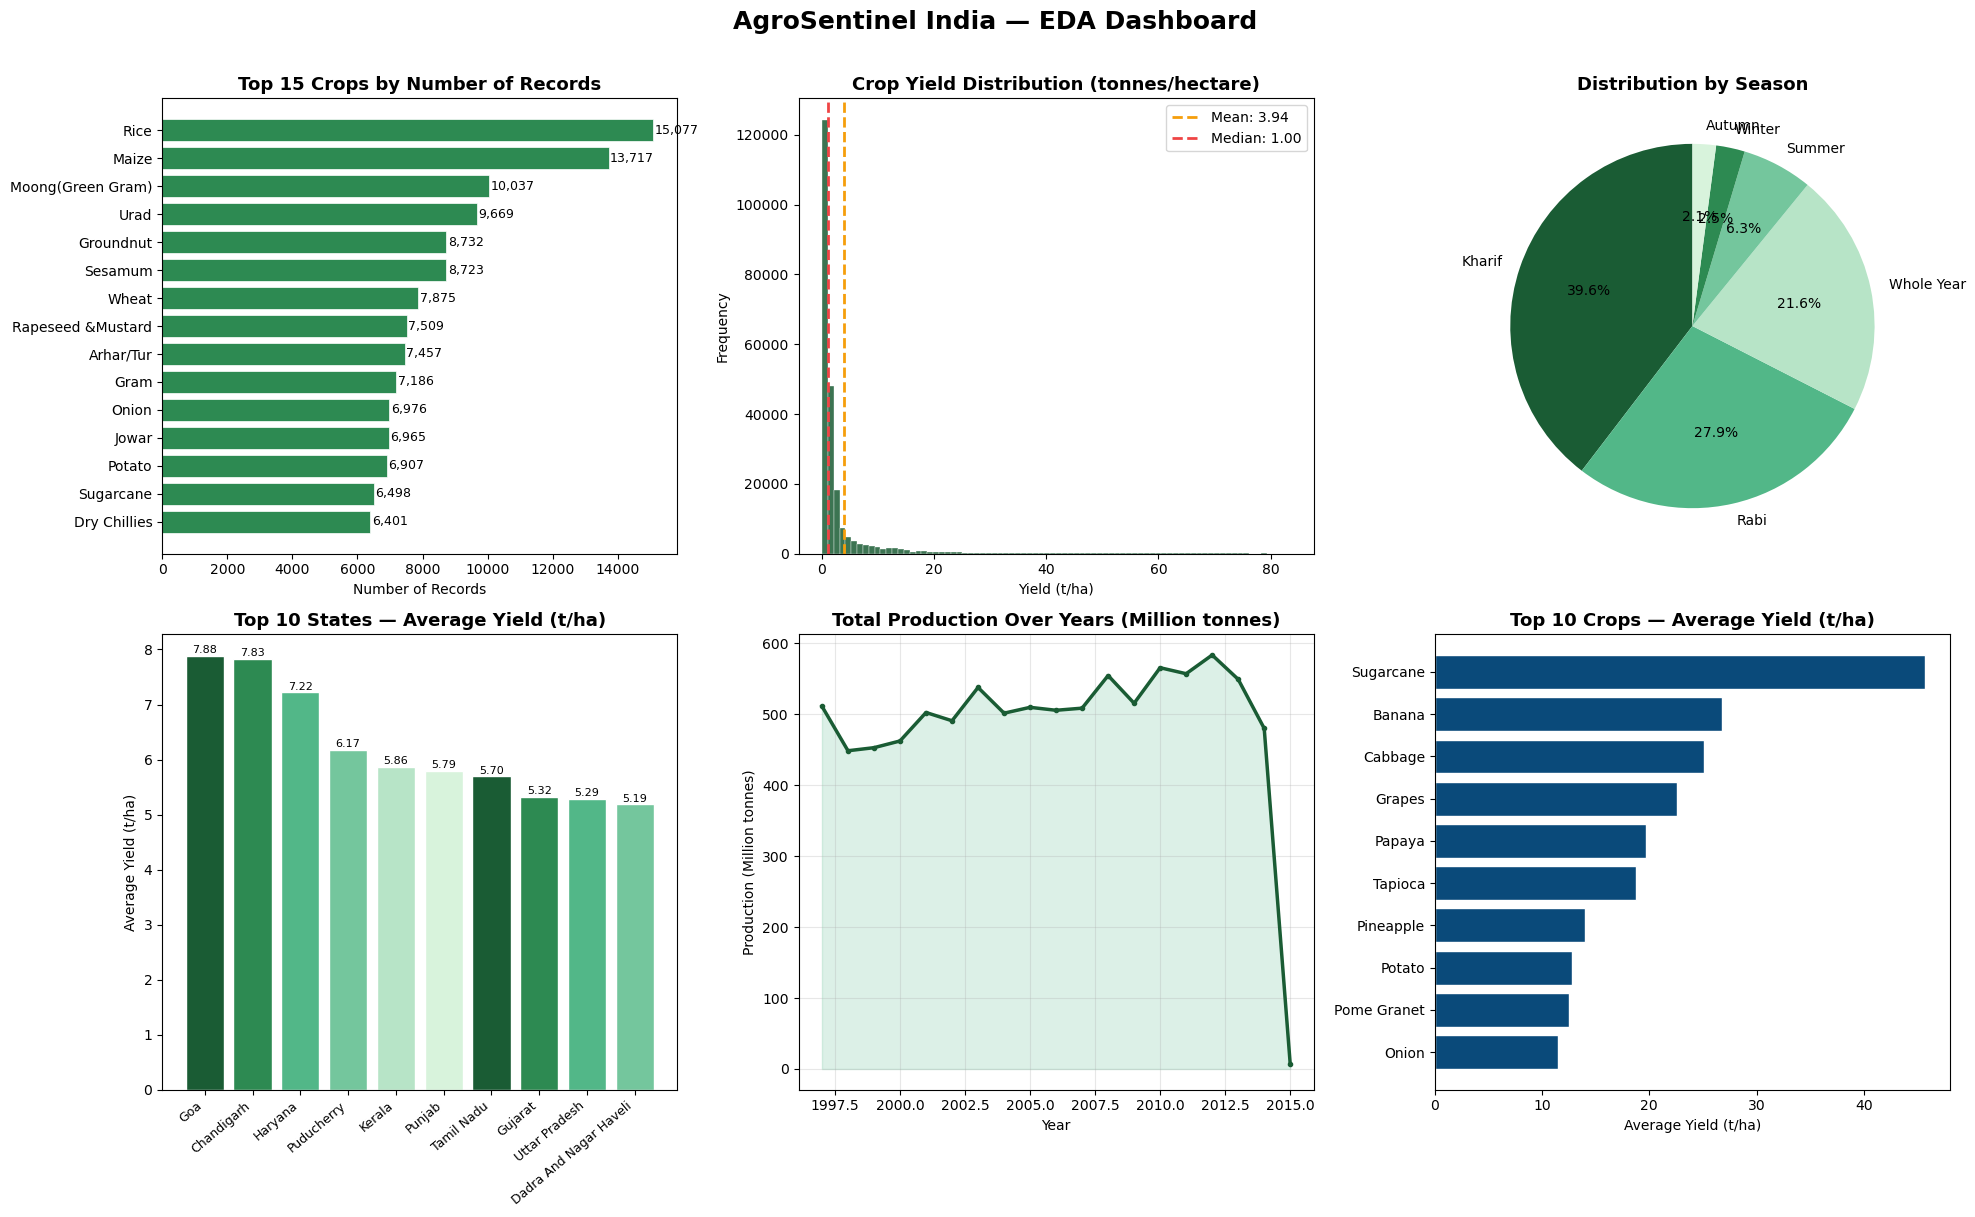

✅ EDA Part 1 saved


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('AgroSentinel India — EDA Dashboard', fontsize=18, fontweight='bold', y=1.01)

colors = ['#1a5c34','#2d8a52','#52b788','#74c69d','#b7e4c7','#d8f3dc']

# 1 — Top 15 crops by record count
top15 = prod_df['crop'].value_counts().head(15)
axes[0,0].barh(top15.index[::-1], top15.values[::-1], color='#2d8a52', edgecolor='white', linewidth=0.5)
axes[0,0].set_title('Top 15 Crops by Number of Records', fontweight='bold', fontsize=13)
axes[0,0].set_xlabel('Number of Records')
for i, v in enumerate(top15.values[::-1]):
    axes[0,0].text(v+50, i, f'{v:,}', va='center', fontsize=9)

# 2 — Yield distribution
axes[0,1].hist(prod_df['yield_tha'], bins=80, color='#1a5c34', edgecolor='white', alpha=0.85, linewidth=0.3)
axes[0,1].set_title('Crop Yield Distribution (tonnes/hectare)', fontweight='bold', fontsize=13)
axes[0,1].set_xlabel('Yield (t/ha)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].axvline(prod_df['yield_tha'].mean(), color='#f59e0b', linestyle='--', linewidth=2, label=f'Mean: {prod_df["yield_tha"].mean():.2f}')
axes[0,1].axvline(prod_df['yield_tha'].median(), color='#ef4444', linestyle='--', linewidth=2, label=f'Median: {prod_df["yield_tha"].median():.2f}')
axes[0,1].legend()

# 3 — Season distribution
season_counts = prod_df['season'].value_counts()
wedge_colors  = ['#1a5c34','#52b788','#b7e4c7','#74c69d','#2d8a52','#d8f3dc']
axes[0,2].pie(season_counts.values, labels=season_counts.index,
              colors=wedge_colors[:len(season_counts)],
              autopct='%1.1f%%', startangle=90, textprops={'fontsize':10})
axes[0,2].set_title('Distribution by Season', fontweight='bold', fontsize=13)

# 4 — Top 10 states by avg yield
state_yield = prod_df.groupby('state')['yield_tha'].mean().sort_values(ascending=False).head(10)
bars = axes[1,0].bar(range(len(state_yield)), state_yield.values, color=colors[:len(state_yield)], edgecolor='white')
axes[1,0].set_xticks(range(len(state_yield)))
axes[1,0].set_xticklabels(state_yield.index, rotation=40, ha='right', fontsize=9)
axes[1,0].set_title('Top 10 States — Average Yield (t/ha)', fontweight='bold', fontsize=13)
axes[1,0].set_ylabel('Average Yield (t/ha)')
for bar, val in zip(bars, state_yield.values):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{val:.2f}', ha='center', fontsize=8)

# 5 — Production over years
year_prod = prod_df.groupby('year')['production'].sum() / 1e6
axes[1,1].plot(year_prod.index, year_prod.values, color='#1a5c34', linewidth=2.5, marker='o', markersize=3)
axes[1,1].fill_between(year_prod.index, year_prod.values, alpha=0.2, color='#52b788')
axes[1,1].set_title('Total Production Over Years (Million tonnes)', fontweight='bold', fontsize=13)
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Production (Million tonnes)')
axes[1,1].grid(alpha=0.3)

# 6 — Top 10 crops by avg yield
crop_yield_avg = prod_df.groupby('crop')['yield_tha'].mean().sort_values(ascending=False).head(10)
axes[1,2].barh(crop_yield_avg.index[::-1], crop_yield_avg.values[::-1], color='#0a4a7a', edgecolor='white')
axes[1,2].set_title('Top 10 Crops — Average Yield (t/ha)', fontweight='bold', fontsize=13)
axes[1,2].set_xlabel('Average Yield (t/ha)')

plt.tight_layout()
plt.savefig('eda_part1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA Part 1 saved")


## 🔗 Step 7 — Feature Correlation Analysis

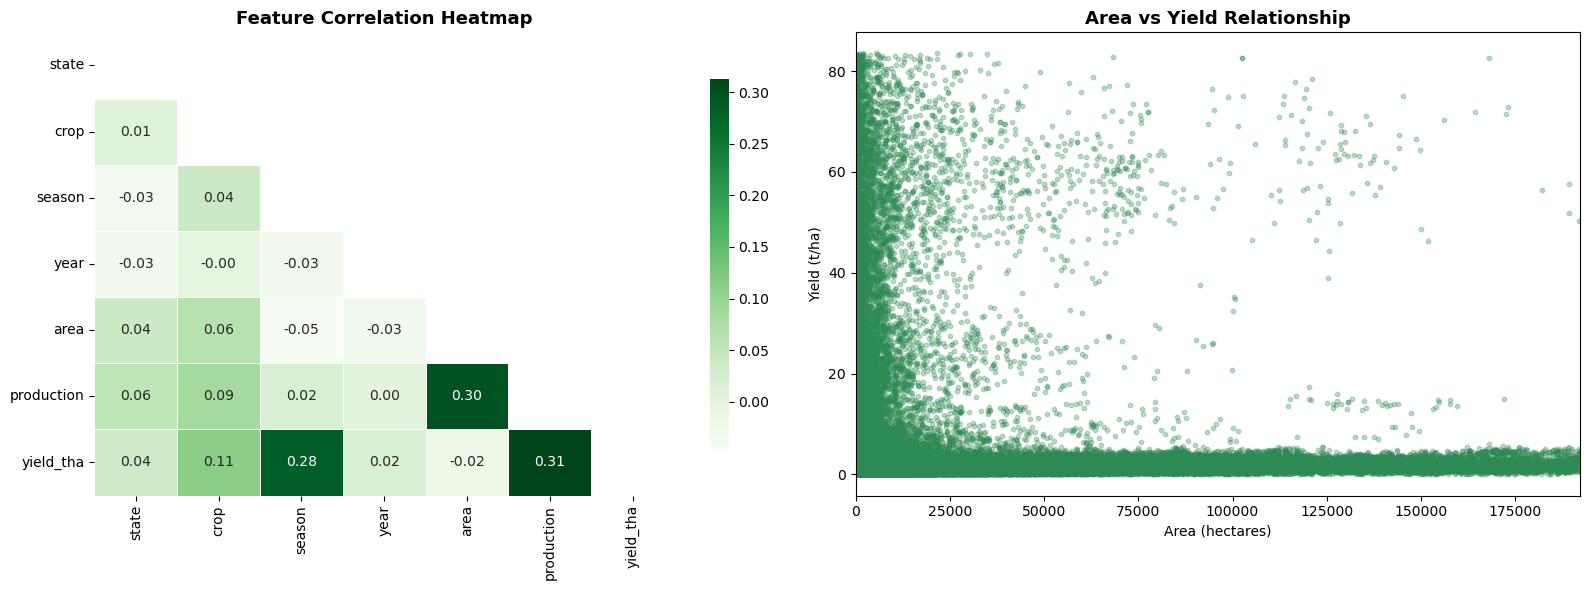

✅ Correlation analysis saved


In [9]:
# Encode for correlation
from sklearn.preprocessing import LabelEncoder

df_corr = prod_df[['state','crop','season','year','area','production','yield_tha']].copy()
for col in ['state','crop','season']:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Greens',
            ax=axes[0], linewidths=0.5, cbar_kws={'shrink':0.8})
axes[0].set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=13)

# Scatter: area vs yield
axes[1].scatter(prod_df['area'], prod_df['yield_tha'], alpha=0.3, color='#2d8a52', s=10)
axes[1].set_xlabel('Area (hectares)')
axes[1].set_ylabel('Yield (t/ha)')
axes[1].set_title('Area vs Yield Relationship', fontweight='bold', fontsize=13)
axes[1].set_xlim(0, prod_df['area'].quantile(0.99))

plt.tight_layout()
plt.savefig('eda_part2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation analysis saved")


## 🤖 Step 8 — Model Building & Comparison
### 6 Algorithms Compared for Each Prediction Task

In [10]:
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              ExtraTreesClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, confusion_matrix
from xgboost import XGBClassifier, XGBRegressor
import joblib

# ── Encode features ──────────────────────────────────────────
df = prod_df.copy()
le_state  = LabelEncoder(); df['state_enc']  = le_state.fit_transform(df['state'])
le_crop   = LabelEncoder(); df['crop_enc']   = le_crop.fit_transform(df['crop'])
le_season = LabelEncoder(); df['season_enc'] = le_season.fit_transform(df['season'])

# Rainfall
RAIN = {"Andhra Pradesh":980,"Arunachal Pradesh":2782,"Assam":2818,"Bihar":1186,
        "Chhattisgarh":1292,"Goa":3005,"Gujarat":820,"Haryana":614,
        "Himachal Pradesh":1251,"Jharkhand":1200,"Karnataka":1139,"Kerala":3055,
        "Madhya Pradesh":1017,"Maharashtra":1177,"Manipur":1467,"Meghalaya":2818,
        "Mizoram":2500,"Nagaland":1900,"Odisha":1451,"Punjab":649,"Rajasthan":531,
        "Sikkim":2740,"Tamil Nadu":998,"Telangana":917,"Tripura":2260,
        "Uttar Pradesh":899,"Uttarakhand":1900,"West Bengal":1582}
df['rainfall'] = df['state'].map(RAIN).fillna(1000)

# Labels
def drought_label(r):
    if r < 500: return 'High'
    elif r < 900: return 'Medium'
    return 'Low'
df['drought_risk'] = df['rainfall'].apply(drought_label)
le_drought = LabelEncoder(); df['drought_enc'] = le_drought.fit_transform(df['drought_risk'])

crop_med = df.groupby('crop')['yield_tha'].transform('median')
df['crop_failure'] = (df['yield_tha'] < crop_med * 0.60).astype(int)

print(f"Master dataset: {len(df):,} records")
print(f"Features ready: state_enc, crop_enc, season_enc, year, rainfall")
print(f"Targets: yield_tha (regression), drought_enc (classification), crop_failure (classification)")


Master dataset: 236,449 records
Features ready: state_enc, crop_enc, season_enc, year, rainfall
Targets: yield_tha (regression), drought_enc (classification), crop_failure (classification)


### 📈 Model 1 — Crop Yield Prediction (Regression)

In [11]:
YIELD_FEAT = ['state_enc','crop_enc','season_enc','year','rainfall']
X = df[YIELD_FEAT].values
y = df['yield_tha'].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

yield_models = {
    "Random Forest":          RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost":                XGBRegressor(n_estimators=200, random_state=42, verbosity=0),
    "Gradient Boosting":      GradientBoostingRegressor(n_estimators=150, random_state=42),
    "Ridge Regression":       Ridge(alpha=1.0),
    "Linear Regression":      LinearRegression(),
}

yield_results = {}
print(f"{'Model':<28} {'R² Score':>10} {'RMSE':>10}")
print("-"*50)
for name, model in yield_models.items():
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    r2   = r2_score(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    yield_results[name] = r2
    print(f"{name:<28} {r2:>10.4f} {rmse:>10.4f}")

best_yield = max(yield_results, key=yield_results.get)
print(f"★ Best Model: {best_yield} (R²={yield_results[best_yield]:.4f})")


Model                          R² Score       RMSE
--------------------------------------------------
Random Forest                    0.9354     2.4265
XGBoost                          0.9344     2.4451
Gradient Boosting                0.8121     4.1377
Ridge Regression                 0.0968     9.0725
Linear Regression                0.0968     9.0725
★ Best Model: Random Forest (R²=0.9354)


### 🌧️ Model 2 — Drought Risk Classification

In [13]:
DROUGHT_FEAT = ['state_enc','crop_enc','season_enc','year','rainfall']
X2 = df[DROUGHT_FEAT].values
y2 = df['drought_enc'].values
X2tr, X2te, y2tr, y2te = train_test_split(X2, y2, test_size=0.2, random_state=42)

drought_models = {
    "Random Forest":     RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost":           XGBClassifier(n_estimators=150, random_state=42, verbosity=0, eval_metric='mlogloss'),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, random_state=42),
    "Extra Trees":       ExtraTreesClassifier(n_estimators=150, random_state=42, n_jobs=-1),
    "KNN":               KNeighborsClassifier(n_neighbors=7),
    "Decision Tree":     DecisionTreeClassifier(max_depth=10, random_state=42),
}

drought_results = {}
print(f"{'Model':<22} {'Accuracy':>12}")
print("-"*36)
for name, model in drought_models.items():
    model.fit(X2tr, y2tr)
    acc = accuracy_score(y2te, model.predict(X2te))
    drought_results[name] = acc
    print(f"{name:<22} {acc*100:>11.2f}%")

best_drought = max(drought_results, key=drought_results.get)
print(f"★ Best Model: {best_drought} (Acc={drought_results[best_drought]*100:.2f}%)")


Model                      Accuracy
------------------------------------
Random Forest               100.00%
XGBoost                     100.00%
Gradient Boosting           100.00%
Extra Trees                 100.00%
KNN                         100.00%
Decision Tree               100.00%
★ Best Model: Random Forest (Acc=100.00%)


### ⚠️ Model 3 — Crop Failure Risk Classification

In [ ]:
FAILURE_FEAT = ['state_enc','crop_enc','season_enc','year','rainfall','yield_tha']
X3 = df[FAILURE_FEAT].values
y3 = df['crop_failure'].values
X3tr, X3te, y3tr, y3te = train_test_split(X3, y3, test_size=0.2, random_state=42)

failure_models = {
    "Random Forest":     RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost":           XGBClassifier(n_estimators=150, random_state=42, verbosity=0, eval_metric='logloss'),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, random_state=42),
    "Extra Trees":       ExtraTreesClassifier(n_estimators=150, random_state=42, n_jobs=-1),
    "KNN":               KNeighborsClassifier(n_neighbors=7),
    "Decision Tree":     DecisionTreeClassifier(max_depth=10, random_state=42),
}

failure_results = {}
print(f"{'Model':<22} {'Accuracy':>12}")
print("-"*36)
for name, model in failure_models.items():
    model.fit(X3tr, y3tr)
    acc = accuracy_score(y3te, model.predict(X3te))
    failure_results[name] = acc
    print(f"{name:<22} {acc*100:>11.2f}%")

best_failure = max(failure_results, key=failure_results.get)
print(f"★ Best Model: {best_failure} (Acc={failure_results[best_failure]*100:.2f}%)")


## 📊 Step 9 — Model Comparison Charts

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('AgroSentinel India — Model Comparison Dashboard', fontsize=16, fontweight='bold')

GREEN_SHADES = ['#1a5c34','#2d8a52','#52b788','#74c69d','#b7e4c7','#d8f3dc']

# Chart 1 — Yield R²
names1 = list(yield_results.keys())
vals1  = [v*100 for v in yield_results.values()]
bars1  = axes[0].bar(range(len(names1)), vals1, color=GREEN_SHADES[:len(names1)], edgecolor='white', width=0.65)
axes[0].set_xticks(range(len(names1)))
axes[0].set_xticklabels(names1, rotation=35, ha='right', fontsize=9)
axes[0].set_ylim(0, 115)
axes[0].set_title('Yield Prediction — R² Score (%)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('R² Score %')
axes[0].axhline(90, color='#ef4444', linestyle='--', linewidth=1.5, alpha=0.7, label='90% threshold')
axes[0].legend(fontsize=9)
for bar, val in zip(bars1, vals1):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Chart 2 — Drought Accuracy
names2 = list(drought_results.keys())
vals2  = [v*100 for v in drought_results.values()]
bars2  = axes[1].bar(range(len(names2)), vals2, color=['#0a4a7a','#1e40af','#3b82f6','#60a5fa','#93c5fd','#bfdbfe'], edgecolor='white', width=0.65)
axes[1].set_xticks(range(len(names2)))
axes[1].set_xticklabels(names2, rotation=35, ha='right', fontsize=9)
axes[1].set_ylim(0, 115)
axes[1].set_title('Drought Risk — Accuracy (%)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Accuracy %')
axes[1].axhline(95, color='#ef4444', linestyle='--', linewidth=1.5, alpha=0.7, label='95% threshold')
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, vals2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Chart 3 — Failure Accuracy
names3 = list(failure_results.keys())
vals3  = [v*100 for v in failure_results.values()]
bars3  = axes[2].bar(range(len(names3)), vals3, color=['#7c2d12','#9a3412','#c2410c','#ea580c','#f97316','#fb923c'], edgecolor='white', width=0.65)
axes[2].set_xticks(range(len(names3)))
axes[2].set_xticklabels(names3, rotation=35, ha='right', fontsize=9)
axes[2].set_ylim(0, 115)
axes[2].set_title('Crop Failure Risk — Accuracy (%)', fontweight='bold', fontsize=13)
axes[2].set_ylabel('Accuracy %')
axes[2].axhline(95, color='#1a5c34', linestyle='--', linewidth=1.5, alpha=0.7, label='95% threshold')
axes[2].legend(fontsize=9)
for bar, val in zip(bars3, vals3):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison chart saved!")


## 🎯 Step 10 — Confusion Matrix (Best Models)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrices — Best Models', fontsize=15, fontweight='bold')

# Drought — Random Forest
best_dr_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
best_dr_model.fit(X2tr, y2tr)
dr_pred = best_dr_model.predict(X2te)
ConfusionMatrixDisplay.from_predictions(y2te, dr_pred,
    display_labels=le_drought.classes_,
    cmap='Greens', ax=axes[0], colorbar=False)
axes[0].set_title(f'Drought Risk — Random Forest\nAccuracy: {accuracy_score(y2te,dr_pred)*100:.2f}%', fontweight='bold')

# Failure — XGBoost
best_fail_model = XGBClassifier(n_estimators=150, random_state=42, verbosity=0, eval_metric='logloss')
best_fail_model.fit(X3tr, y3tr)
fail_pred = best_fail_model.predict(X3te)
ConfusionMatrixDisplay.from_predictions(y3te, fail_pred,
    display_labels=['No Failure','Crop Failure'],
    cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title(f'Crop Failure — XGBoost\nAccuracy: {accuracy_score(y3te,fail_pred)*100:.2f}%', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved!")


## 🔑 Step 11 — Feature Importance

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_names_yield = ['State','Crop','Season','Year','Rainfall']

# Yield — RF feature importance
rf_yield = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_yield.fit(Xtr, ytr)
fi_yield = rf_yield.feature_importances_

axes[0].barh(feat_names_yield, fi_yield, color=['#1a5c34','#2d8a52','#52b788','#74c69d','#b7e4c7'])
axes[0].set_title('Feature Importance — Yield Prediction\n(Random Forest)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Importance Score')
for i, v in enumerate(fi_yield):
    axes[0].text(v+0.005, i, f'{v:.3f}', va='center', fontsize=10)

# Drought — RF feature importance
best_dr_model2 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
best_dr_model2.fit(X2tr, y2tr)
fi_drought = best_dr_model2.feature_importances_

axes[1].barh(feat_names_yield, fi_drought, color=['#0a4a7a','#1e40af','#3b82f6','#60a5fa','#93c5fd'])
axes[1].set_title('Feature Importance — Drought Risk\n(Random Forest)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Importance Score')
for i, v in enumerate(fi_drought):
    axes[1].text(v+0.005, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance charts saved!")


## ✅ Step 12 — Final Summary

In [ ]:
print("="*65)
print("  AgroSentinel India — Project Summary")
print("="*65)
print(f"\n📊 Dataset:")
print(f"  Records   : {len(df):,}")
print(f"  Crops     : {df['crop'].nunique()}")
print(f"  States    : {df['state'].nunique()}")
print(f"  Seasons   : {list(df['season'].unique())}")
print(f"  Year range: {int(df['year'].min())} — {int(df['year'].max())}")

print(f"\n🤖 Best Models:")
print(f"  Yield Prediction : {best_yield} — R²={yield_results[best_yield]*100:.2f}%")
print(f"  Drought Risk     : {best_drought} — Acc={drought_results[best_drought]*100:.2f}%")
print(f"  Failure Risk     : {best_failure} — Acc={failure_results[best_failure]*100:.2f}%")

print(f"\n🎯 SDG Impact:")
print(f"  SDG 2 — Zero Hunger     : Better crop yield predictions → food security")
print(f"  SDG 15 — Life on Land   : Drought risk awareness → sustainable farming")

print(f"\n🌐 Application:")
print(f"  Backend  : Flask API v4.0 — 12 endpoints")
print(f"  Frontend : React.js — 8 modules, 6 languages")
print(f"  Modules  : Yield · Drought · Failure · Season · Irrigation")
print(f"             Pest Risk · Price Forecast · Govt Schemes · AI Advisory")

print(f"\n✅ Project complete and ready for deployment!")
